In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri


In [3]:
import os

print(os.listdir(path))

['Training', 'Testing']


In [4]:
train_dir = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"

test_dir = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing"

In [5]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten,BatchNormalization,Dropout,GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers
from tensorflow.keras.layers import Input
from keras.applications.vgg16 import VGG16

2026-05-20 06:19:03.307374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779257943.711293      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779257943.832811      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779257944.942144      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779257944.942207      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779257944.942210      57 computation_placer.cc:177] computation placer alr

In [6]:
conv_base = VGG16(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224,224,3)

)
conv_base.summary()

I0000 00:00:1779257985.886417      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779257985.892332      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
conv_base.trainable = False

In [8]:
model = Sequential()
model.add(conv_base)
model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4,activation='softmax'))

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,934,596 (68.42 MB)

 Trainable params: 3,219,908 (12.28 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
train_set = keras.utils.image_dataset_from_directory(
    directory=train_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224,224),
    validation_split=0.2,
    subset='training',
    seed=123
)

val_set = keras.utils.image_dataset_from_directory(
    directory=train_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224,224),
    validation_split=0.2,
    subset='validation',
    seed=123
)

Found 2870 files belonging to 4 classes.
Using 2296 files for training.
Found 2870 files belonging to 4 classes.
Using 574 files for validation.


In [11]:
def process(image , label):
  image  = tensorflow.cast(image/255. , tensorflow.float32)
  return image,label

train_set = train_set.map(process)
val_set = val_set.map(process)

In [12]:
model.compile(optimizer='adam',loss = "sparse_categorical_crossentropy",metrics=['accuracy'])

In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0,
)

In [14]:
history= model.fit(train_set,epochs=100,validation_data=val_set,callbacks=[early_stop])

Epoch 1/100


I0000 00:00:1779258042.025314     156 service.cc:152] XLA service 0x793b10414420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779258042.025352     156 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779258042.025355     156 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779258042.838342     156 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/72 ━━━━━━━━━━━━━━━━━━━━ 19:57 17s/step - accuracy: 0.2188 - loss: 2.4429

I0000 00:00:1779258056.852934     156 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 536ms/step - accuracy: 0.4481 - loss: 1.6506 - val_accuracy: 0.6916 - val_loss: 0.7685
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 211ms/step - accuracy: 0.6477 - loss: 0.8276 - val_accuracy: 0.8084 - val_loss: 0.5762
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 217ms/step - accuracy: 0.7171 - loss: 0.6515 - val_accuracy: 0.8206 - val_loss: 0.5143
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 227ms/step - accuracy: 0.7355 - loss: 0.6219 - val_accuracy: 0.8467 - val_loss: 0.3845
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 235ms/step - accuracy: 0.7911 - loss: 0.4798 - val_accuracy: 0.8554 - val_loss: 0.3485
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 233ms/step - accuracy: 0.8259 - loss: 0.3952 - val_accuracy: 0.8711 - val_loss: 0.3031
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 229ms/step - accuracy: 0.8611 - loss: 0.3460 - val_accuracy: 0.8972 - val_loss: 0.2826
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 227ms/step - accuracy: 0.8768 - loss: 0.2991 - val_accuracy

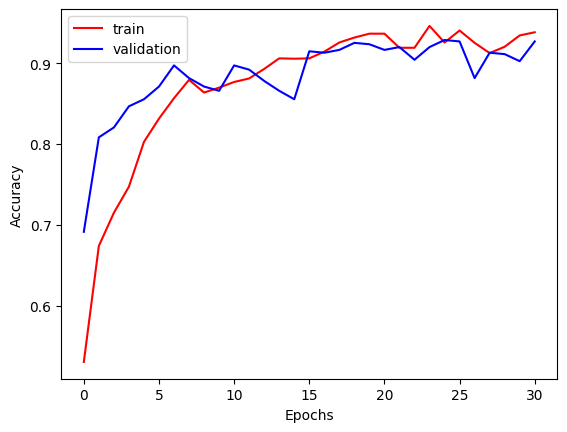

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')

plt.plot(history.history['val_accuracy'], color='blue', label='validation')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

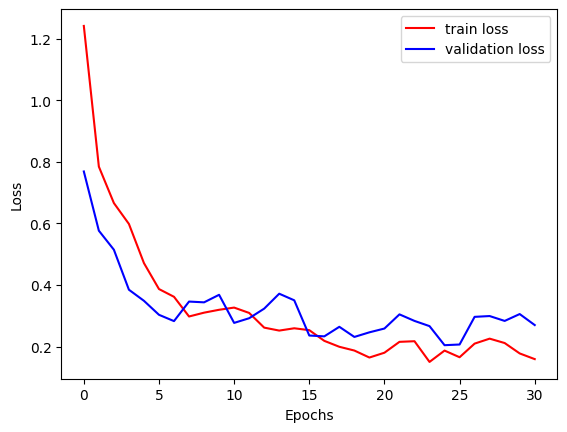

In [16]:
plt.plot(history.history['loss'], color='red', label='train loss')

plt.plot(history.history['val_loss'], color='blue', label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [21]:
test_set = keras.utils.image_dataset_from_directory(
    directory=test_dir,
    labels="inferred",
    label_mode='int',
    batch_size=32,
    image_size=(224,224),
    shuffle=False
)

print(test_set.class_names)

Found 394 files belonging to 4 classes.
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [22]:
test_set = test_set.map(process)

In [23]:
test_loss, test_accuracy = model.evaluate(test_set)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 633ms/step - accuracy: 0.5455 - loss: 3.8337
Test Accuracy: 0.7385786771774292
Test Loss: 1.842604160308838


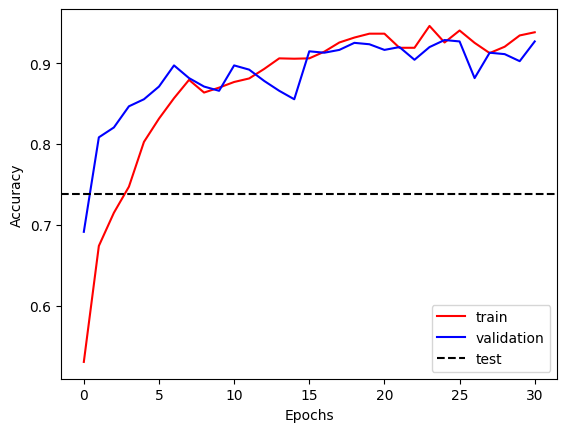

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')

plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.axhline(y=test_accuracy,
            color='black',
            linestyle='--',
            label='test')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

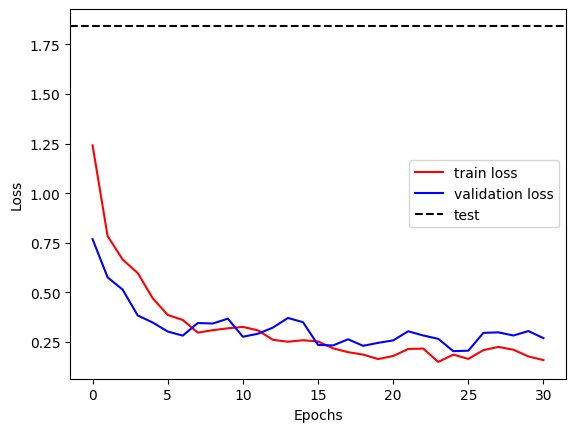

In [25]:
plt.plot(history.history['loss'], color='red', label='train loss')

plt.plot(history.history['val_loss'], color='blue', label='validation loss')
plt.axhline(y=test_loss,
            color='black',
            linestyle='--',
            label='test')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

plt.show()